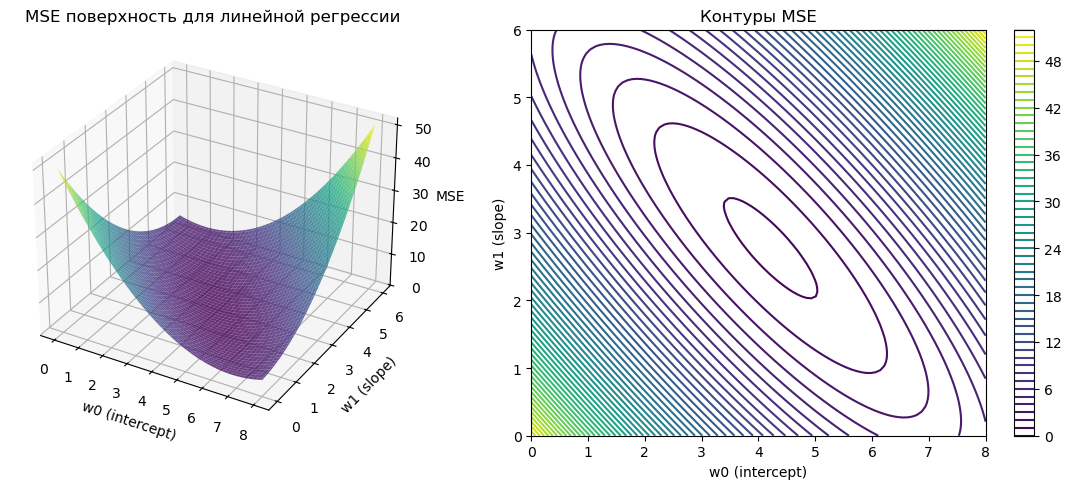

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Генерируем простые данные
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Создаем сетку для параметров w0 и w1
w0_range = np.linspace(0, 8, 100)  # intercept
w1_range = np.linspace(0, 6, 100)  # slope
W0, W1 = np.meshgrid(w0_range, w1_range)

# Вычисляем MSE для каждой комбинации w0, w1
mse_values = np.zeros(W0.shape)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        y_pred = W0[i, j] + W1[i, j] * X
        mse_values[i, j] = np.mean((y - y_pred) ** 2)

# 3D визуализация
fig = plt.figure(figsize=(12, 5))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W0, W1, mse_values, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w0 (intercept)')
ax1.set_ylabel('w1 (slope)')
ax1.set_zlabel('MSE')
ax1.set_title('MSE поверхность для линейной регрессии')

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(W0, W1, mse_values, levels=50)
ax2.set_xlabel('w0 (intercept)')
ax2.set_ylabel('w1 (slope)')
ax2.set_title('Контуры MSE')
plt.colorbar(contour)

plt.tight_layout()
plt.show()

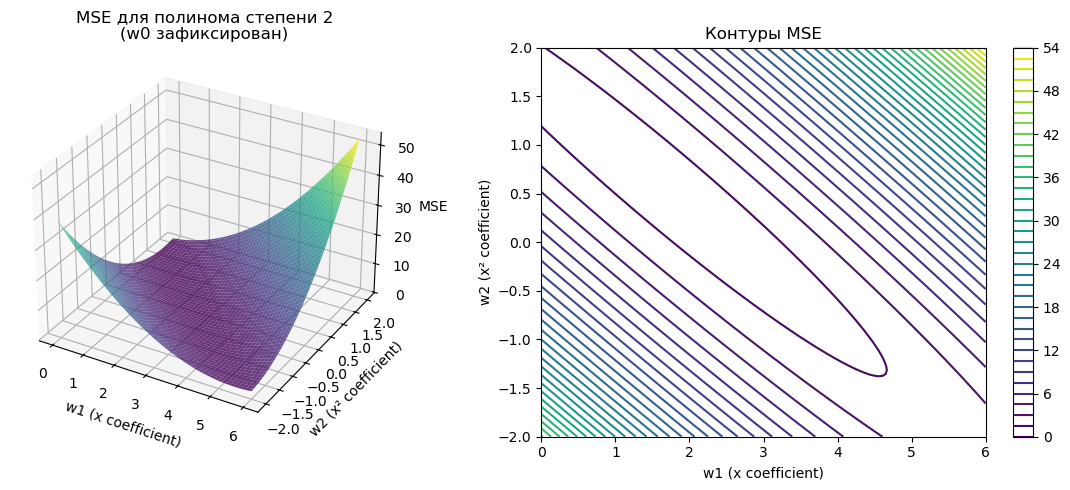

In [2]:
# Для полинома степени 2: y = w0 + w1*x + w2*x²
# Мы не можем визуализировать 4D пространство, поэтому зафиксируем w0

# Создаем полиномиальные признаки
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Зафиксируем w0 на оптимальном значении
model = LinearRegression()
model.fit(X_poly, y)
optimal_w0 = model.intercept_[0]

# Сетка для w1 и w2
w1_range = np.linspace(0, 6, 100)
w2_range = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

# Вычисляем MSE для каждой комбинации w1, w2 при фиксированном w0
mse_values_poly = np.zeros(W1.shape)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        # X_poly уже содержит [1, x, x²]
        # Мы используем фиксированный w0 и варьируем w1, w2
        y_pred = optimal_w0 + W1[i, j] * X + W2[i, j] * (X**2)
        mse_values_poly[i, j] = np.mean((y - y_pred) ** 2)

# Визуализация
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W1, W2, mse_values_poly, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w1 (x coefficient)')
ax1.set_ylabel('w2 (x² coefficient)')
ax1.set_zlabel('MSE')
ax1.set_title('MSE для полинома степени 2\n(w0 зафиксирован)')

ax2 = fig.add_subplot(122)
contour = ax2.contour(W1, W2, mse_values_poly, levels=50)
ax2.set_xlabel('w1 (x coefficient)')
ax2.set_ylabel('w2 (x² coefficient)')
ax2.set_title('Контуры MSE')
plt.colorbar(contour)

plt.tight_layout()
plt.show()

In [ ]:
def gradient_descent_visualization(X, y, learning_rate=0.1, n_iterations=50):
    # Инициализация весов
    w = np.random.randn(2, 1)
    
    # Сохраняем историю весов и MSE
    w_history = [w.copy()]
    mse_history = []
    
    for i in range(n_iterations):
        # Вычисляем градиент
        gradients = -2 * X.T.dot(y - X.dot(w)) / len(X)
        
        # Обновляем веса
        w = w - learning_rate * gradients
        
        # Сохраняем историю
        w_history.append(w.copy())
        mse = np.mean((y - X.dot(w)) ** 2)
        mse_history.append(mse)
    
    return np.array(w_history), np.array(mse_history)

# Добавляем столбец единиц для intercept
X_with_bias = np.c_[np.ones((100, 1)), X]

# Запускаем градиентный спуск
w_history, mse_history = gradient_descent_visualization(X_with_bias, y)

# Визуализируем траекторию
fig = plt.figure(figsize=(12, 5))

# Траектория на контурном графике
ax1 = fig.add_subplot(121)
contour = ax1.contour(W0, W1, mse_values, levels=50)
ax1.plot(w_history[:, 0], w_history[:, 1], 'ro-', markersize=4, linewidth=2)
ax1.set_xlabel('w0 (intercept)')
ax1.set_ylabel('w1 (slope)')
ax1.set_title('Траектория градиентного спуска')

# Сходимость MSE
ax2 = fig.add_subplot(122)
ax2.plot(mse_history)
ax2.set_xlabel('Итерация')
ax2.set_ylabel('MSE')
ax2.set_title('Сходимость MSE')
ax2.grid(True)

plt.tight_layout()
plt.show()